LOADING WS-DREAM DATASET
RT shape: (339, 5825)
TP shape: (339, 5825)

Expected Dataset 1 dimensions: 339 x 5825


Q1 - BASIC SUMMARY

Response Time
--------------------------------------------------
Total observations : 1974675
Missing values     : 100837
Zero values        : 0
Negative values    : 0
Positive values    : 1873838
Minimum value      : 0.001
Maximum value      : 19.999
Range              : 19.997999999999998

Throughput
--------------------------------------------------
Total observations : 1974675
Missing values     : 143422
Zero values        : 0
Negative values    : 0
Positive values    : 1831253
Minimum value      : 0.004
Maximum value      : 1000.0
Range              : 999.996


Q2 - DATA PREPROCESSING

Preprocessing strategy:

1. Convert -1 to NaN because WS-DREAM uses -1 for unavailable/
   invalid QoS measurements.

2. Do not treat -1 as a numerical measurement.

3. Identify zero and negative values separately.

4. For the subsequent continuous QoS analysis, retai

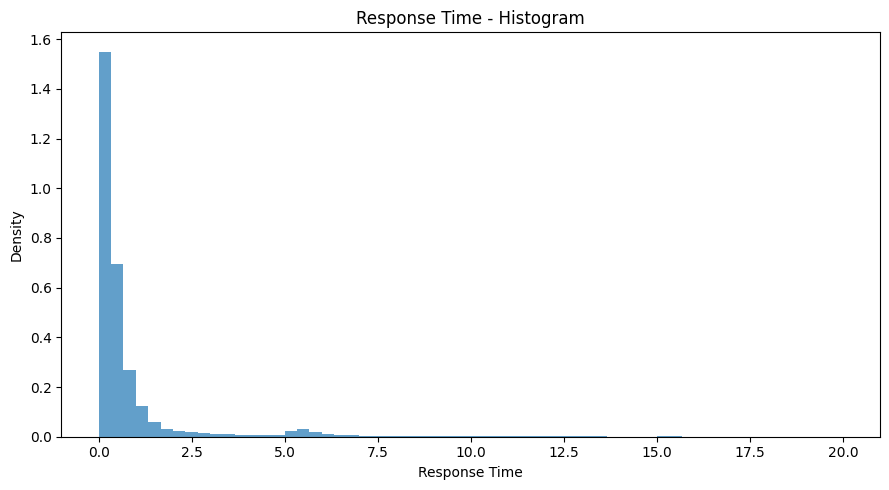

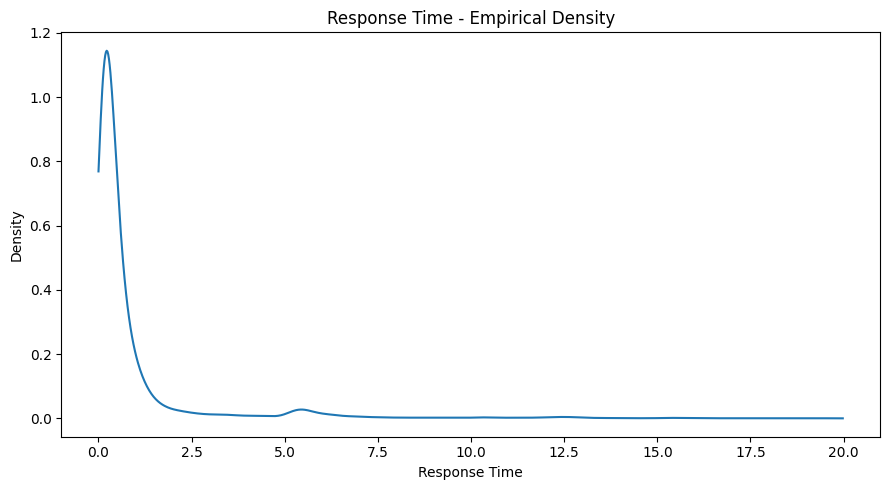

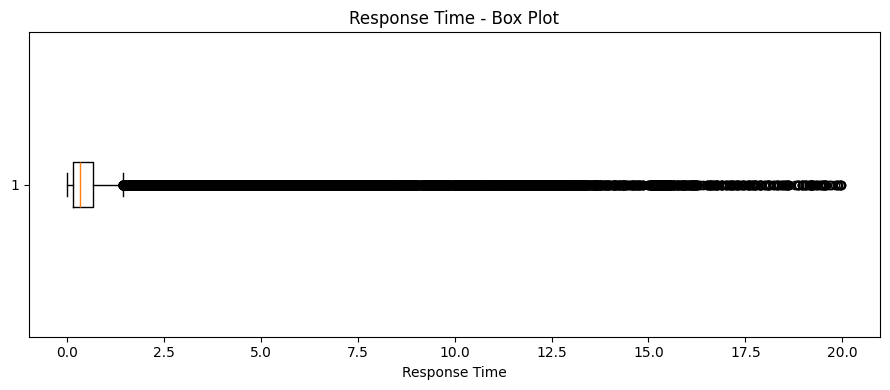

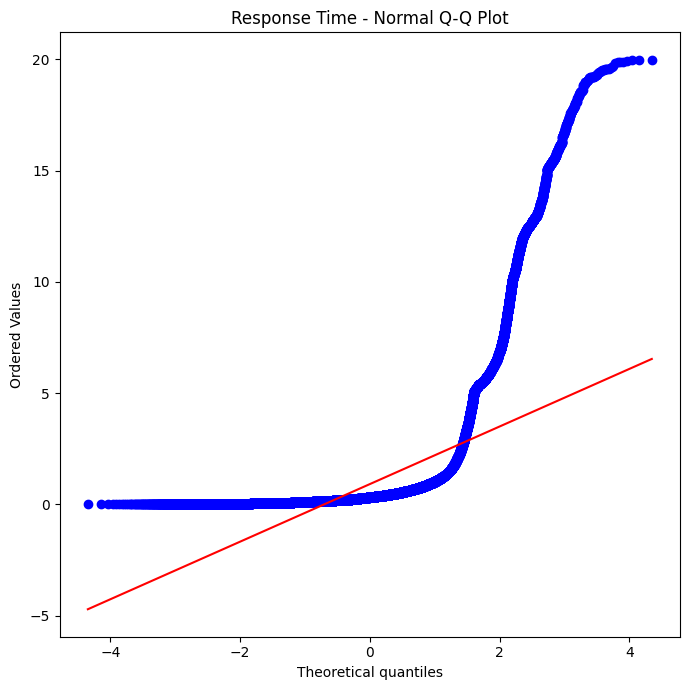

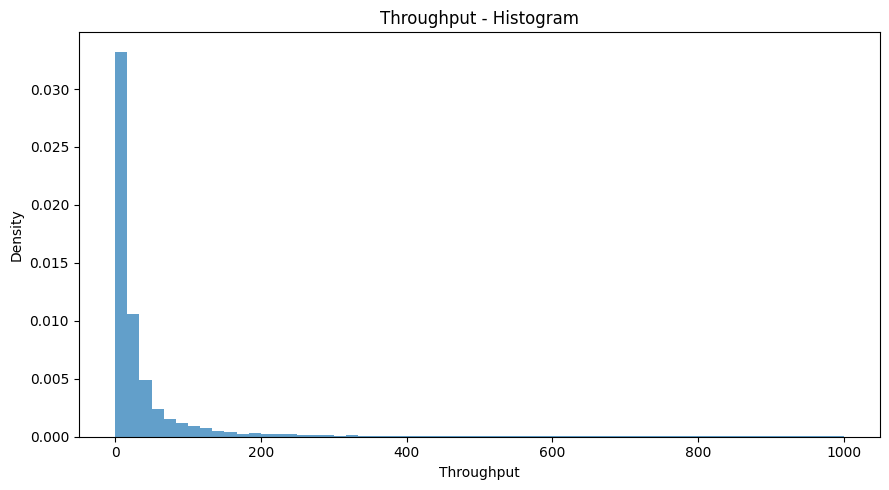

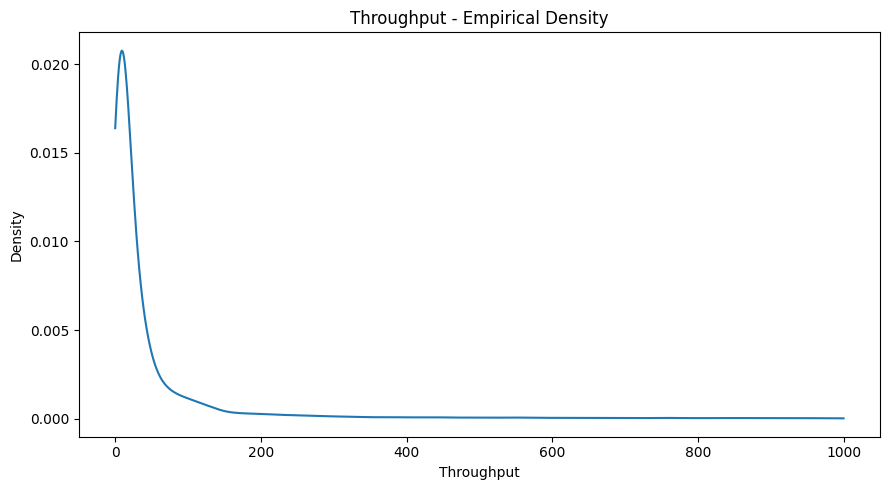

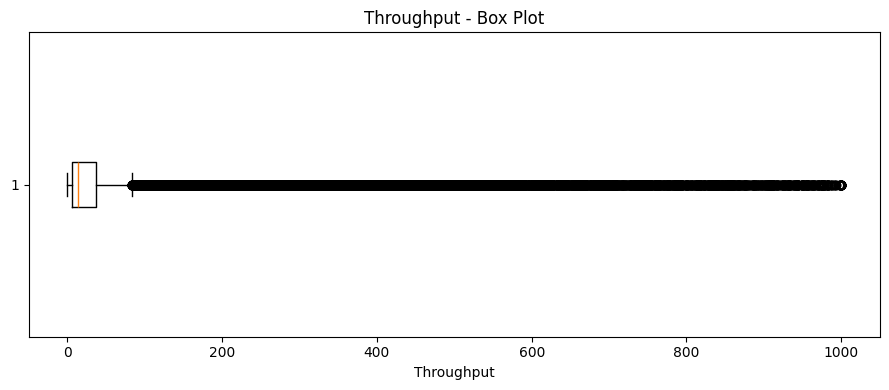

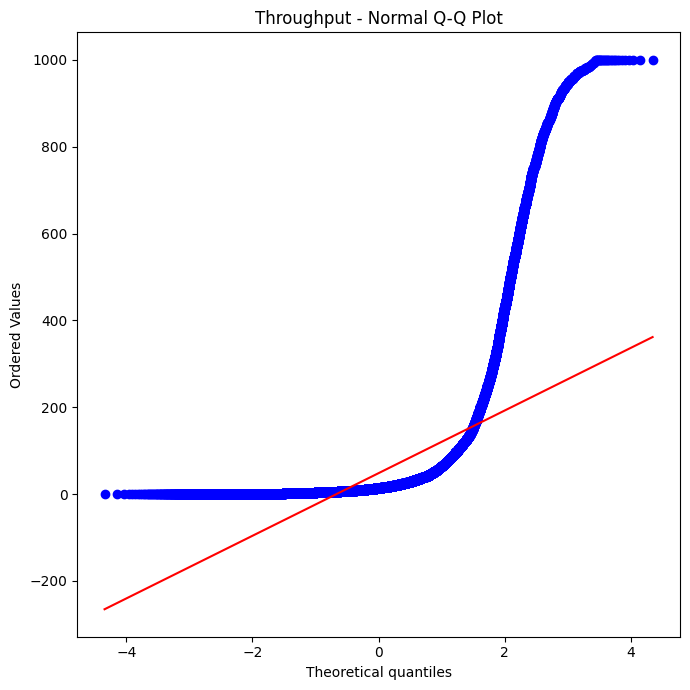



Q6 - FIRST FOUR RAW MOMENTS OF RT
Raw moment 1 : 0.9085700861013596
Raw moment 2 : 4.716976047263959
Raw moment 3 : 46.70022834545278
Raw moment 4 : 575.8178781772771

Interpretation:

μ'1 = E[X]       -> arithmetic mean/location.

μ'2 = E[X²]      -> second raw moment; used with E[X] to
                    calculate variance.

μ'3 = E[X³]      -> third raw moment; contains information
                    about asymmetry when combined appropriately
                    into central moments.

μ'4 = E[X⁴]      -> fourth raw moment; contributes to measuring
                    tail heaviness/kurtosis after centralization.



Q7 - FIRST FOUR CENTRAL MOMENTS OF RT
Central moment μ1: 2.8527306574369747e-16
Central moment μ2: 3.8914764459057256
Central moment μ3: 35.343166833016134
Central moment μ4: 427.4149785264208

Variance: 3.8914764459057256
Skewness: 4.603984486457952
Pearson Kurtosis: 28.224153503455046
Excess Kurtosis: 25.224153503455046


Q8 - EXPECTATION AND VARIANCE
E[X]       = 

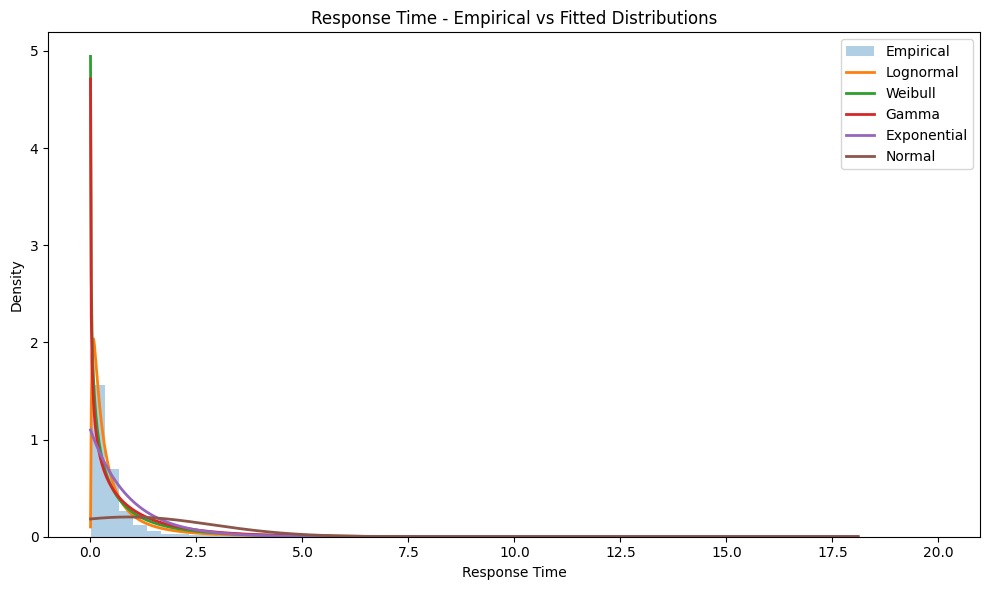

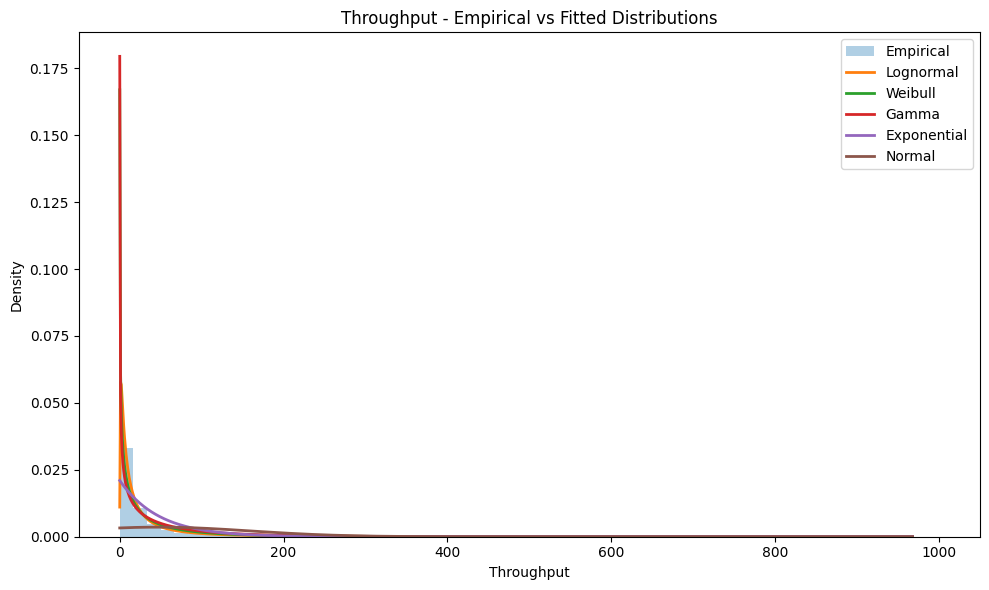



Q16 - 95% CONFIDENCE INTERVAL FOR RT MEAN
Sample size: 1873838
Mean: 0.9085700861013596
Sample SD: 1.9726830770927104
Standard error: 0.001441090642003075
95% CI: (np.float64(0.9057455985201589), np.float64(0.9113945736825603))

Assumption:

The original RT distribution need not itself be normal for the
large-sample confidence interval because the Central Limit Theorem
makes the sampling distribution of the mean approximately normal
for sufficiently large n, provided observations are not dominated
by pathological dependence.



Q17 - CI FOR VARIANCE AND STANDARD DEVIATION
Sample variance: 3.8914785226479642
95% variance CI: (np.float64(3.8836107896873706), np.float64(3.899370298567121))
95% SD CI: (np.float64(1.9706878975848434), np.float64(1.9746823285194814))

Bootstrap variance CI
Bootstrap 95% variance CI: [3.77809968 4.13771386]


Q18 - ONE SAMPLE HYPOTHESIS TEST

Q18 requires a specified population mean from the assignment/
instructor.

No value has been invented here.

Set:

 

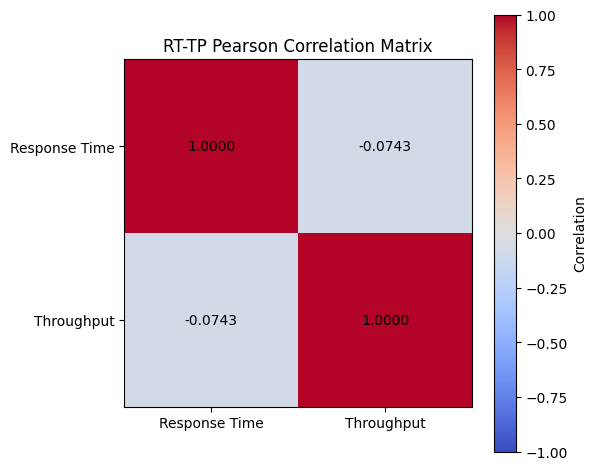



Q28 - CENTRAL LIMIT THEOREM

n = 10
Mean of sample means: 0.8864184
SD of sample means: 0.6126272190340876


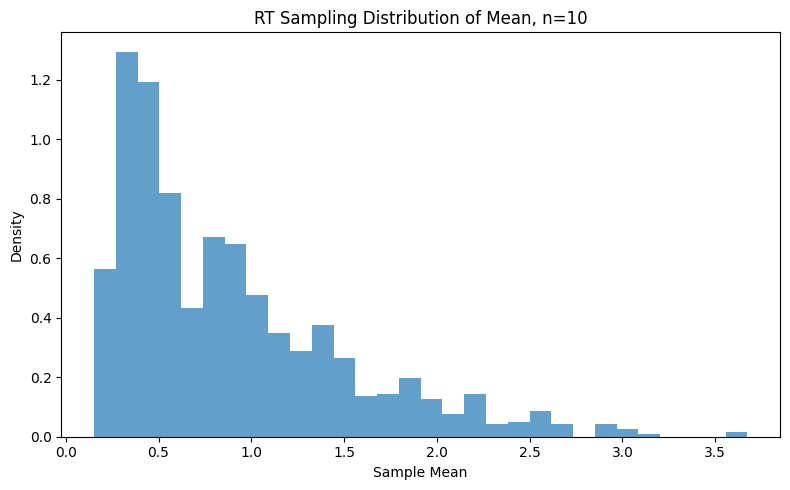


n = 30
Mean of sample means: 0.9123363
SD of sample means: 0.355150696523601


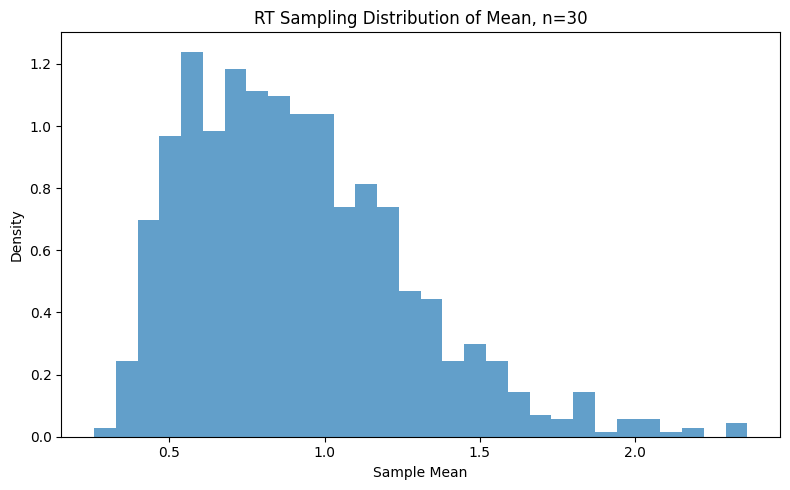


n = 50
Mean of sample means: 0.90916958
SD of sample means: 0.27074675937012355


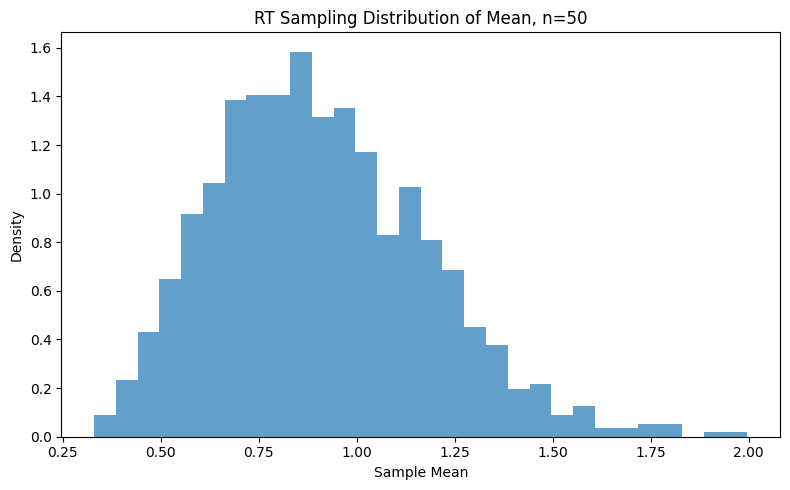


n = 100
Mean of sample means: 0.91187048
SD of sample means: 0.1994313860468547


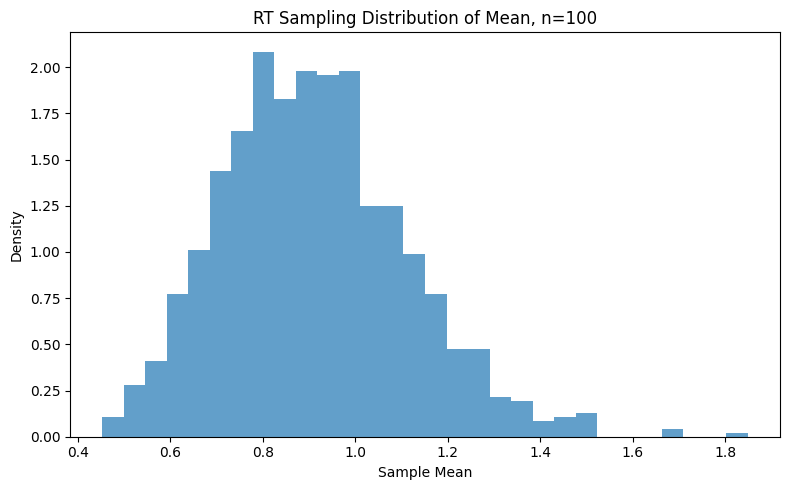



Q29-Q31 - TWO-COMPONENT GAUSSIAN MIXTURE

Mixing coefficients:
π1 = 0.8389823421099277
π2 = 0.16101765789007227

Means:
μ1 = 0.3271973947947574
μ2 = 3.9405970233153473

Variances:
σ1² = 0.06377384137783565
σ2² = 12.896206917674133

Iterations: 35
Final log-likelihood: -82309.66371280418

Q31 steps implemented:

(a) Initialize parameters
(b) E-step: calculate component responsibilities
(c) M-step: update mixing coefficients, means and variances
(d) Calculate log-likelihood
(e) Repeat until convergence



Q32 - GMM VISUALIZATION


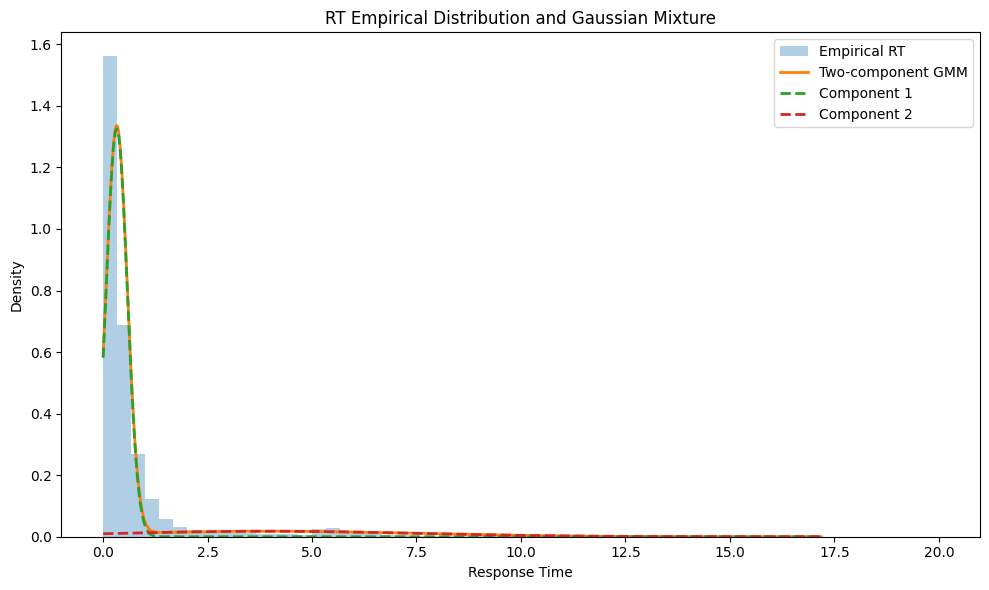



Q33 - EFFECT OF DIFFERENT INITIALIZATIONS
Initial percentiles      mu1      mu2     var1      var2      pi1      pi2  iterations        loglik
              20/80 0.327197 3.940599 0.063774 12.896210 0.838982 0.161018          34 -82309.663713
              25/75 0.327198 3.940601 0.063774 12.896213 0.838983 0.161017          34 -82309.663713
              30/70 0.327197 3.940597 0.063774 12.896207 0.838982 0.161018          35 -82309.663713
              40/60 0.327198 3.940601 0.063774 12.896212 0.838983 0.161017          35 -82309.663713
              10/90 0.327198 3.940602 0.063774 12.896214 0.838983 0.161017          33 -82309.663713


Q34 - GMM VS SINGLE GAUSSIAN
Single Gaussian log-likelihood: -209863.8833460602
GMM log-likelihood: -82309.66371280418

Single Gaussian AIC: 419731.7666921204
GMM AIC: 164629.32742560835

Single Gaussian BIC: 419750.79254305037
GMM BIC: 164676.8920529332

AIC conclusion: GMM provides better fit.
BIC conclusion: GMM provides better fit.


Q35 - EM

In [14]:
# ================================================================
# WS-DREAM QoS DATASET
# COMPLETE STATISTICAL ANALYSIS - Q1 TO Q36
#
# Dataset:
#   rtMatrix.txt -> Response Time
#   tpMatrix.txt -> Throughput
#
# Dataset dimensions:
#   339 users x 5825 web services
#
# IMPORTANT:
#   -1 in WS-DREAM means unavailable/invalid QoS measurement.
#   It is therefore converted to NaN before analysis.
#
# Selected QoS variable for Q6-Q9, Q16-Q18, Q28-Q35:
#   Response Time (RT)
# ================================================================


# ================================================================
# 0. IMPORT LIBRARIES
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    norm,
    expon,
    gamma,
    lognorm,
    weibull_min,
    chi2,
    t
)

from scipy.optimize import minimize

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


# ================================================================
# 1. SETTINGS
# ================================================================

# Folder containing the dataset files
DATA_DIR = "."

RT_FILE = os.path.join(DATA_DIR, "rtMatrix.txt")
TP_FILE = os.path.join(DATA_DIR, "tpMatrix.txt")
USER_FILE = os.path.join(DATA_DIR, "userlist.txt")
WS_FILE = os.path.join(DATA_DIR, "wslist.txt")

ALPHA = 0.05
CONFIDENCE = 0.95

# ------------------------------------------------
# Q18:
# Enter the value specified by your instructor.
#
# Example:
# HYPOTHESIS_MEAN = 1.0
#
# Do NOT leave 1.0 unless 1.0 is actually specified.
# ------------------------------------------------

HYPOTHESIS_MEAN = None


# ------------------------------------------------
# Q19-Q21:
# Select two users.
#
# Row 0 = first user
# Row 1 = second user
# etc.
#
# These SAME two users are used in Q19, Q20 and Q21.
# ------------------------------------------------

GROUP_A_ROW = 0
GROUP_B_ROW = 1


# ------------------------------------------------
# Computational settings
# ------------------------------------------------

# Distribution fitting and EM do not need all ~2 million
# observations to estimate parameters efficiently.
#
# Q1-Q9 and other descriptive calculations use ALL
# valid observations.
#
# Distribution fitting / EM use a reproducible random sample.
# ------------------------------------------------

FIT_SAMPLE_SIZE = 100000
EM_SAMPLE_SIZE = 100000

# Number of bootstrap repetitions for Q17
BOOTSTRAP_REPETITIONS = 2000

# Number of CLT repetitions
CLT_REPETITIONS = 1000


# ================================================================
# 2. LOAD DATA
# ================================================================

print("=" * 75)
print("LOADING WS-DREAM DATASET")
print("=" * 75)


if not os.path.exists(RT_FILE):
    raise FileNotFoundError(
        f"Cannot find {RT_FILE}. "
        f"Put rtMatrix.txt in {DATA_DIR}."
    )

if not os.path.exists(TP_FILE):
    raise FileNotFoundError(
        f"Cannot find {TP_FILE}. "
        f"Put tpMatrix.txt in {DATA_DIR}."
    )


# WS-DREAM matrices are whitespace-separated.
rt = pd.read_csv(
    RT_FILE,
    sep=r"\s+",
    header=None,
    engine="python"
)

tp = pd.read_csv(
    TP_FILE,
    sep=r"\s+",
    header=None,
    engine="python"
)


# Convert everything to numeric
rt = rt.apply(pd.to_numeric, errors="coerce")
tp = tp.apply(pd.to_numeric, errors="coerce")


print("RT shape:", rt.shape)
print("TP shape:", tp.shape)


# ================================================================
# 3. VERIFY DATASET DIMENSIONS
# ================================================================

print("\nExpected Dataset 1 dimensions: 339 x 5825")

if rt.shape != (339, 5825):
    print(
        "WARNING: RT matrix does not have expected dimensions."
    )

if tp.shape != (339, 5825):
    print(
        "WARNING: TP matrix does not have expected dimensions."
    )


# ================================================================
# 4. CONVERT -1 TO NaN
# ================================================================

# This is REQUIRED by the assignment.

rt.replace(-1, np.nan, inplace=True)
tp.replace(-1, np.nan, inplace=True)


# Flatten matrices for overall statistical analysis
rt_all = rt.to_numpy(dtype=float).ravel()
tp_all = tp.to_numpy(dtype=float).ravel()


# ================================================================
# HELPER FUNCTIONS
# ================================================================

def valid_positive(data):
    """
    Return finite, strictly positive observations.
    """
    data = np.asarray(data, dtype=float)

    return data[
        np.isfinite(data) &
        (data > 0)
    ]


def basic_counts(data):
    """
    Count missing, zero and negative values.
    """

    data = np.asarray(data, dtype=float)

    missing = np.sum(np.isnan(data))

    finite = data[np.isfinite(data)]

    zero = np.sum(finite == 0)

    negative = np.sum(finite < 0)

    positive = np.sum(finite > 0)

    return {
        "total": len(data),
        "missing": int(missing),
        "zero": int(zero),
        "negative": int(negative),
        "positive": int(positive)
    }


def modal_class(data, bins=50):

    counts, edges = np.histogram(
        data,
        bins=bins
    )

    i = np.argmax(counts)

    lower = edges[i]
    upper = edges[i + 1]

    return lower, upper, counts[i]


def descriptive_table(data, name):

    data = valid_positive(data)

    q1 = np.percentile(data, 25)
    q2 = np.percentile(data, 50)
    q3 = np.percentile(data, 75)

    mean = np.mean(data)
    median = np.median(data)

    minimum = np.min(data)
    maximum = np.max(data)

    variance = np.var(data)
    std = np.std(data)

    cv = std / mean

    skewness = stats.skew(
        data,
        bias=False
    )

    # Fisher kurtosis:
    # normal distribution = 0
    kurtosis_excess = stats.kurtosis(
        data,
        fisher=True,
        bias=False
    )

    # Pearson kurtosis:
    # normal distribution = 3
    kurtosis_pearson = kurtosis_excess + 3

    mode_low, mode_high, mode_count = modal_class(data)

    result = {
        "Variable": name,
        "N": len(data),
        "Mean": mean,
        "Median": median,
        "Modal class lower": mode_low,
        "Modal class upper": mode_high,
        "Modal class frequency": mode_count,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": maximum - minimum,
        "Q1": q1,
        "Q2": q2,
        "Q3": q3,
        "IQR": q3 - q1,
        "Population Variance": np.var(data, ddof=0),
        "Sample Variance": np.var(data, ddof=1),
        "Population SD": np.std(data, ddof=0),
        "Sample SD": np.std(data, ddof=1),
        "CV": cv,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis_excess,
        "Pearson Kurtosis": kurtosis_pearson
    }

    return result


def random_sample(data, size):

    data = np.asarray(data)

    if len(data) <= size:
        return data.copy()

    return np.random.choice(
        data,
        size=size,
        replace=False
    )


# ================================================================
# Q1
# BASIC SUMMARY
# ================================================================

print("\n")
print("=" * 75)
print("Q1 - BASIC SUMMARY")
print("=" * 75)


rt_counts = basic_counts(rt_all)
tp_counts = basic_counts(tp_all)


rt_valid = valid_positive(rt_all)
tp_valid = valid_positive(tp_all)


def print_q1(name, data, counts):

    minimum = np.min(data)
    maximum = np.max(data)

    print("\n" + name)
    print("-" * 50)

    print("Total observations :", counts["total"])
    print("Missing values     :", counts["missing"])
    print("Zero values        :", counts["zero"])
    print("Negative values    :", counts["negative"])
    print("Positive values    :", counts["positive"])

    print("Minimum value      :", minimum)
    print("Maximum value      :", maximum)
    print("Range              :", maximum - minimum)


print_q1(
    "Response Time",
    rt_valid,
    rt_counts
)

print_q1(
    "Throughput",
    tp_valid,
    tp_counts
)


# ================================================================
# Q2
# DATA PREPROCESSING
# ================================================================

print("\n")
print("=" * 75)
print("Q2 - DATA PREPROCESSING")
print("=" * 75)

print("""
Preprocessing strategy:

1. Convert -1 to NaN because WS-DREAM uses -1 for unavailable/
   invalid QoS measurements.

2. Do not treat -1 as a numerical measurement.

3. Identify zero and negative values separately.

4. For the subsequent continuous QoS analysis, retain only
   finite positive measurements.

5. Missing values are removed rather than mean/median imputed.

Justification:
The dataset is very large, and -1 represents an unavailable
measurement rather than a value that should be estimated from
the observed distribution. Imputation would introduce artificial
QoS observations and could affect variance, skewness, kurtosis,
distribution fitting and outlier analysis.

Therefore, complete valid positive observations are used for
the main statistical analysis.
""")


print("\nRT preprocessing:")
print("Original:", len(rt_all))
print("After cleaning:", len(rt_valid))
print("Removed:", len(rt_all) - len(rt_valid))


print("\nTP preprocessing:")
print("Original:", len(tp_all))
print("After cleaning:", len(tp_valid))
print("Removed:", len(tp_all) - len(tp_valid))


# ================================================================
# Q3
# DESCRIPTIVE STATISTICS
# ================================================================

print("\n")
print("=" * 75)
print("Q3 - DESCRIPTIVE STATISTICS")
print("=" * 75)


rt_desc = descriptive_table(
    rt_valid,
    "Response Time"
)

tp_desc = descriptive_table(
    tp_valid,
    "Throughput"
)


desc_df = pd.DataFrame(
    [rt_desc, tp_desc]
)

pd.set_option(
    "display.max_columns",
    None
)

print(desc_df.T)


# ================================================================
# Q4
# POPULATION VS SAMPLE
# ================================================================

print("\n")
print("=" * 75)
print("Q4 - POPULATION AND SAMPLE ESTIMATES")
print("=" * 75)


def population_sample_results(data, name):

    print("\n" + name)
    print("-" * 50)

    print(
        "Population mean      :",
        np.mean(data)
    )

    print(
        "Sample mean          :",
        np.mean(data)
    )

    print(
        "Population variance  :",
        np.var(data, ddof=0)
    )

    print(
        "Sample variance      :",
        np.var(data, ddof=1)
    )

    print(
        "Population SD        :",
        np.std(data, ddof=0)
    )

    print(
        "Sample SD            :",
        np.std(data, ddof=1)
    )


population_sample_results(
    rt_valid,
    "Response Time"
)

population_sample_results(
    tp_valid,
    "Throughput"
)


print("""
Interpretation:

Population parameters describe the complete set of valid
observations under consideration.

Sample statistics estimate parameters of a larger population.

For this assignment, the WS-DREAM matrix is a fixed observed
dataset, so descriptive quantities calculated using all valid
records can be interpreted as empirical population characteristics.
When making inferential statements about a broader population of
QoS measurements, sample estimates are appropriate.
""")


# ================================================================
# Q5
# HISTOGRAM, DENSITY, BOX PLOT, Q-Q PLOT
# ================================================================

print("\n")
print("=" * 75)
print("Q5 - DISTRIBUTION VISUALIZATION")
print("=" * 75)


def plot_distribution(data, name):

    # Histogram
    plt.figure(figsize=(9, 5))
    plt.hist(
        data,
        bins=60,
        density=True,
        alpha=0.7
    )
    plt.xlabel(name)
    plt.ylabel("Density")
    plt.title(name + " - Histogram")
    plt.tight_layout()
    plt.show()

    # Empirical density
    sample = random_sample(
        data,
        100000
    )

    kde = stats.gaussian_kde(sample)

    x = np.linspace(
        np.min(sample),
        np.max(sample),
        1000
    )

    plt.figure(figsize=(9, 5))
    plt.plot(
        x,
        kde(x)
    )
    plt.xlabel(name)
    plt.ylabel("Density")
    plt.title(name + " - Empirical Density")
    plt.tight_layout()
    plt.show()

    # Box plot
    plt.figure(figsize=(9, 4))
    plt.boxplot(
        sample,
        vert=False
    )
    plt.xlabel(name)
    plt.title(name + " - Box Plot")
    plt.tight_layout()
    plt.show()

    # Q-Q plot
    plt.figure(figsize=(7, 7))
    stats.probplot(
        sample,
        dist="norm",
        plot=plt
    )
    plt.title(name + " - Normal Q-Q Plot")
    plt.tight_layout()
    plt.show()


plot_distribution(
    rt_valid,
    "Response Time"
)

plot_distribution(
    tp_valid,
    "Throughput"
)


# ================================================================
# Q6
# FIRST FOUR RAW MOMENTS - RT
# ================================================================

print("\n")
print("=" * 75)
print("Q6 - FIRST FOUR RAW MOMENTS OF RT")
print("=" * 75)


rt_mean = np.mean(rt_valid)

raw_moments = {
    "Raw moment 1": np.mean(rt_valid ** 1),
    "Raw moment 2": np.mean(rt_valid ** 2),
    "Raw moment 3": np.mean(rt_valid ** 3),
    "Raw moment 4": np.mean(rt_valid ** 4)
}

for key, value in raw_moments.items():
    print(key, ":", value)


print("""
Interpretation:

μ'1 = E[X]       -> arithmetic mean/location.

μ'2 = E[X²]      -> second raw moment; used with E[X] to
                    calculate variance.

μ'3 = E[X³]      -> third raw moment; contains information
                    about asymmetry when combined appropriately
                    into central moments.

μ'4 = E[X⁴]      -> fourth raw moment; contributes to measuring
                    tail heaviness/kurtosis after centralization.
""")


# ================================================================
# Q7
# FIRST FOUR CENTRAL MOMENTS - RT
# ================================================================

print("\n")
print("=" * 75)
print("Q7 - FIRST FOUR CENTRAL MOMENTS OF RT")
print("=" * 75)


mu = np.mean(rt_valid)

central_moments = {}

for k in range(1, 5):

    central_moments[k] = np.mean(
        (rt_valid - mu) ** k
    )

for k, value in central_moments.items():

    print(
        f"Central moment μ{k}:",
        value
    )


mu1 = central_moments[1]
mu2 = central_moments[2]
mu3 = central_moments[3]
mu4 = central_moments[4]


central_variance = mu2

central_skewness = (
    mu3 /
    (mu2 ** 1.5)
)

central_kurtosis = (
    mu4 /
    (mu2 ** 2)
)

central_excess_kurtosis = (
    central_kurtosis - 3
)


print("\nVariance:", central_variance)
print("Skewness:", central_skewness)
print("Pearson Kurtosis:", central_kurtosis)
print("Excess Kurtosis:", central_excess_kurtosis)


# ================================================================
# Q8
# EXPECTATION AND VARIANCE
# ================================================================

print("\n")
print("=" * 75)
print("Q8 - EXPECTATION AND VARIANCE")
print("=" * 75)


E_X = np.mean(rt_valid)
E_X2 = np.mean(rt_valid ** 2)

variance_formula = (
    E_X2 -
    E_X ** 2
)

variance_direct = np.var(
    rt_valid,
    ddof=0
)

print("E[X]       =", E_X)
print("E[X²]      =", E_X2)

print("\nVar(X) = E[X²] - (E[X])²")

print(
    "Variance from formula =",
    variance_formula
)

print(
    "Direct population variance =",
    variance_direct
)

print(
    "Difference =",
    abs(
        variance_formula -
        variance_direct
    )
)


# ================================================================
# Q9
# STANDARDIZED MOMENTS - RT
# ================================================================

print("\n")
print("=" * 75)
print("Q9 - STANDARDIZED MOMENTS")
print("=" * 75)


sigma = np.std(
    rt_valid,
    ddof=0
)

z = (
    rt_valid - E_X
) / sigma


for k in range(1, 5):

    value = np.mean(z ** k)

    print(
        f"Standardized moment {k}:",
        value
    )


print("""
Interpretation:

Third standardized moment = skewness.

Fourth standardized moment = Pearson kurtosis.

Positive skewness indicates a longer right tail.
A Pearson kurtosis greater than 3 indicates heavier tails
than a normal distribution.
""")


# ================================================================
# Q10-Q15
# PROBABILITY DISTRIBUTION ANALYSIS
# ================================================================

print("\n")
print("=" * 75)
print("Q10-Q15 - PROBABILITY DISTRIBUTION ANALYSIS")
print("=" * 75)


# Candidate distributions
DISTRIBUTIONS = {
    "Normal": norm,
    "Exponential": expon,
    "Gamma": gamma,
    "Lognormal": lognorm,
    "Weibull": weibull_min
}


def fit_distribution(
    data,
    dist_name,
    dist
):

    try:

        if dist_name == "Normal":

            params = dist.fit(data)

        else:

            # Positive-support distributions
            params = dist.fit(
                data,
                floc=0
            )

        logpdf_values = dist.logpdf(
            data,
            *params
        )

        log_likelihood = np.sum(
            logpdf_values[
                np.isfinite(logpdf_values)
            ]
        )

        k = len(params)

        n = len(data)

        aic = (
            2 * k -
            2 * log_likelihood
        )

        bic = (
            k * np.log(n) -
            2 * log_likelihood
        )

        # KS statistic
        ks_stat, ks_p = stats.kstest(
            data,
            dist.cdf,
            args=params
        )

        return {
            "Distribution": dist_name,
            "Parameters": params,
            "LogLikelihood": log_likelihood,
            "AIC": aic,
            "BIC": bic,
            "KS Statistic": ks_stat,
            "KS p-value": ks_p
        }

    except Exception as e:

        print(
            "Could not fit",
            dist_name,
            ":",
            e
        )

        return None


def fit_all_distributions(
    data,
    name
):

    sample = random_sample(
        data,
        FIT_SAMPLE_SIZE
    )

    results = []

    for dist_name, dist in DISTRIBUTIONS.items():

        result = fit_distribution(
            sample,
            dist_name,
            dist
        )

        if result is not None:

            results.append(result)

    result_df = pd.DataFrame(
        results
    )

    result_df = result_df.sort_values(
        by="AIC"
    )

    print("\n" + name)
    print("-" * 70)

    print(
        result_df[
            [
                "Distribution",
                "LogLikelihood",
                "AIC",
                "BIC",
                "KS Statistic",
                "KS p-value"
            ]
        ].to_string(index=False)
    )

    return result_df, sample


rt_fit_results, rt_fit_sample = fit_all_distributions(
    rt_valid,
    "Response Time"
)

tp_fit_results, tp_fit_sample = fit_all_distributions(
    tp_valid,
    "Throughput"
)


# ================================================================
# Q10
# EMPIRICAL DISTRIBUTION INTERPRETATION
# ================================================================

print("\n")
print("=" * 75)
print("Q10 - DISTRIBUTION INTERPRETATION")
print("=" * 75)

print("""
The candidate models considered are:

1. Normal
2. Exponential
3. Gamma
4. Lognormal
5. Weibull

RT and TP are positive continuous QoS variables. Therefore,
positive-support distributions such as Gamma, Lognormal and
Weibull are especially relevant when the empirical distributions
are right-skewed.

The final choice must be based on Q11-Q15 using AIC, BIC,
KS statistic/p-value and graphical comparison.
""")


# ================================================================
# Q11
# AT LEAST THREE CANDIDATE DISTRIBUTIONS
# ================================================================

print("\n")
print("=" * 75)
print("Q11 - CANDIDATE DISTRIBUTIONS")
print("=" * 75)


print(
    "RT candidates:",
    list(rt_fit_results["Distribution"])
)

print(
    "TP candidates:",
    list(tp_fit_results["Distribution"])
)


# ================================================================
# Q12
# MLE - LIKELIHOOD AND LOG-LIKELIHOOD
# ================================================================

print("\n")
print("=" * 75)
print("Q12 - MAXIMUM LIKELIHOOD ESTIMATION")
print("=" * 75)


print("""
For observations x1,...,xn and parameter vector θ:

Likelihood:
    L(θ) = Π f(xi | θ)

Log-likelihood:
    l(θ) = Σ log f(xi | θ)

MLE:
    θ_hat = argmax l(θ)

The fitted scipy distribution parameters above are obtained
by maximum likelihood. The code also reports the resulting
log-likelihood, AIC and BIC.
""")


# ================================================================
# Q13
# METHOD OF MOMENTS
# ================================================================

print("\n")
print("=" * 75)
print("Q13 - METHOD OF MOMENTS")
print("=" * 75)


def exponential_mom(data):

    mean = np.mean(data)

    # For exponential:
    # E[X] = scale
    return mean


def gamma_mom(data):

    mean = np.mean(data)

    variance = np.var(
        data,
        ddof=0
    )

    # Gamma:
    # mean = alpha * theta
    # variance = alpha * theta^2
    #
    # alpha = mean^2 / variance
    # theta = variance / mean

    alpha = (
        mean ** 2 /
        variance
    )

    theta = (
        variance /
        mean
    )

    return alpha, theta


rt_exp_mom = exponential_mom(rt_fit_sample)
rt_gamma_mom = gamma_mom(rt_fit_sample)

tp_exp_mom = exponential_mom(tp_fit_sample)
tp_gamma_mom = gamma_mom(tp_fit_sample)


print("RT Exponential MoM scale:")
print(rt_exp_mom)

print("\nRT Gamma MoM:")
print(
    "Shape =", rt_gamma_mom[0],
    "Scale =", rt_gamma_mom[1]
)

print("\nTP Exponential MoM scale:")
print(tp_exp_mom)

print("\nTP Gamma MoM:")
print(
    "Shape =", tp_gamma_mom[0],
    "Scale =", tp_gamma_mom[1]
)


# ================================================================
# Q14
# MLE VS MOM
# ================================================================

print("\n")
print("=" * 75)
print("Q14 - MLE VS METHOD OF MOMENTS")
print("=" * 75)


def print_mle_for(
    results,
    distribution_name
):

    row = results[
        results["Distribution"] ==
        distribution_name
    ]

    if len(row) == 0:
        return

    print(
        distribution_name,
        "MLE parameters:",
        row.iloc[0]["Parameters"]
    )


print("Response Time:")
print_mle_for(
    rt_fit_results,
    "Exponential"
)
print_mle_for(
    rt_fit_results,
    "Gamma"
)

print("\nThroughput:")
print_mle_for(
    tp_fit_results,
    "Exponential"
)
print_mle_for(
    tp_fit_results,
    "Gamma"
)


print("""
Differences between MLE and MoM arise because:

MLE selects parameters that maximize the likelihood of the
observed sample.

MoM selects parameters so that theoretical moments match
sample moments.

MLE often has strong large-sample properties, whereas MoM
is usually simpler to derive and calculate.
""")


# ================================================================
# Q15
# BEST-FITTING DISTRIBUTION
# ================================================================

print("\n")
print("=" * 75)
print("Q15 - BEST FITTING DISTRIBUTION")
print("=" * 75)


def best_distribution(result_df):

    # Primary criterion: AIC
    best = result_df.iloc[0]

    print(
        "Best distribution by AIC:",
        best["Distribution"]
    )

    print(
        "AIC:",
        best["AIC"]
    )

    print(
        "BIC:",
        best["BIC"]
    )

    print(
        "KS statistic:",
        best["KS Statistic"]
    )

    print(
        "KS p-value:",
        best["KS p-value"]
    )

    print(
        "Parameters:",
        best["Parameters"]
    )


print("\nResponse Time")
best_distribution(
    rt_fit_results
)

print("\nThroughput")
best_distribution(
    tp_fit_results
)


# ================================================================
# Q15 GRAPHICAL DISTRIBUTION COMPARISON
# ================================================================

def plot_fitted_distributions(
    data,
    result_df,
    name
):

    sample = random_sample(
        data,
        50000
    )

    x = np.linspace(
        np.min(sample),
        np.percentile(sample, 99.9),
        1000
    )

    plt.figure(figsize=(10, 6))

    plt.hist(
        sample,
        bins=60,
        density=True,
        alpha=0.35,
        label="Empirical"
    )

    for _, row in result_df.iterrows():

        dist_name = row["Distribution"]
        params = row["Parameters"]

        dist = DISTRIBUTIONS[
            dist_name
        ]

        y = dist.pdf(
            x,
            *params
        )

        plt.plot(
            x,
            y,
            linewidth=2,
            label=dist_name
        )

    plt.xlabel(name)
    plt.ylabel("Density")
    plt.title(
        name +
        " - Empirical vs Fitted Distributions"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


plot_fitted_distributions(
    rt_valid,
    rt_fit_results,
    "Response Time"
)

plot_fitted_distributions(
    tp_valid,
    tp_fit_results,
    "Throughput"
)


# ================================================================
# Q16
# 95% CI FOR MEAN OF RT
# ================================================================

print("\n")
print("=" * 75)
print("Q16 - 95% CONFIDENCE INTERVAL FOR RT MEAN")
print("=" * 75)


n_rt = len(rt_valid)

mean_rt = np.mean(rt_valid)

sample_sd_rt = np.std(
    rt_valid,
    ddof=1
)

se_rt = (
    sample_sd_rt /
    np.sqrt(n_rt)
)

critical_t = t.ppf(
    0.975,
    df=n_rt - 1
)

mean_ci_lower = (
    mean_rt -
    critical_t * se_rt
)

mean_ci_upper = (
    mean_rt +
    critical_t * se_rt
)

print("Sample size:", n_rt)
print("Mean:", mean_rt)
print("Sample SD:", sample_sd_rt)
print("Standard error:", se_rt)

print(
    "95% CI:",
    (
        mean_ci_lower,
        mean_ci_upper
    )
)


print("""
Assumption:

The original RT distribution need not itself be normal for the
large-sample confidence interval because the Central Limit Theorem
makes the sampling distribution of the mean approximately normal
for sufficiently large n, provided observations are not dominated
by pathological dependence.
""")


# ================================================================
# Q17
# CI FOR VARIANCE AND STANDARD DEVIATION
# ================================================================

print("\n")
print("=" * 75)
print("Q17 - CI FOR VARIANCE AND STANDARD DEVIATION")
print("=" * 75)


n = len(rt_valid)

sample_variance = np.var(
    rt_valid,
    ddof=1
)

alpha = 0.05

chi2_low = chi2.ppf(
    alpha / 2,
    df=n - 1
)

chi2_high = chi2.ppf(
    1 - alpha / 2,
    df=n - 1
)

variance_ci_low = (
    (n - 1) *
    sample_variance /
    chi2_high
)

variance_ci_high = (
    (n - 1) *
    sample_variance /
    chi2_low
)

sd_ci_low = np.sqrt(
    variance_ci_low
)

sd_ci_high = np.sqrt(
    variance_ci_high
)

print("Sample variance:", sample_variance)
print(
    "95% variance CI:",
    (
        variance_ci_low,
        variance_ci_high
    )
)

print(
    "95% SD CI:",
    (
        sd_ci_low,
        sd_ci_high
    )
)


# ------------------------------------------------
# Bootstrap CI for variance
# ------------------------------------------------

print("\nBootstrap variance CI")

bootstrap_variances = []

# Use a manageable bootstrap sample size
# because the original dataset is very large.

bootstrap_base = random_sample(
    rt_valid,
    min(50000, len(rt_valid))
)

for i in range(
    BOOTSTRAP_REPETITIONS
):

    sample = np.random.choice(
        bootstrap_base,
        size=len(bootstrap_base),
        replace=True
    )

    bootstrap_variances.append(
        np.var(
            sample,
            ddof=1
        )
    )


bootstrap_variances = np.array(
    bootstrap_variances
)

bootstrap_ci = np.percentile(
    bootstrap_variances,
    [2.5, 97.5]
)

print(
    "Bootstrap 95% variance CI:",
    bootstrap_ci
)


# ================================================================
# Q18
# ONE-SAMPLE HYPOTHESIS TEST
# ================================================================

print("\n")
print("=" * 75)
print("Q18 - ONE SAMPLE HYPOTHESIS TEST")
print("=" * 75)


if HYPOTHESIS_MEAN is None:

    print("""
Q18 requires a specified population mean from the assignment/
instructor.

No value has been invented here.

Set:

    HYPOTHESIS_MEAN = <specified value>

and rerun this section.
""")

else:

    test = stats.ttest_1samp(
        rt_valid,
        popmean=HYPOTHESIS_MEAN
    )

    print(
        "H0: μ =",
        HYPOTHESIS_MEAN
    )

    print(
        "H1: μ !=",
        HYPOTHESIS_MEAN
    )

    print(
        "Test statistic:",
        test.statistic
    )

    print(
        "p-value:",
        test.pvalue
    )

    print(
        "Significance level:",
        ALPHA
    )

    if test.pvalue < ALPHA:

        print(
            "Conclusion: Reject H0."
        )

    else:

        print(
            "Conclusion: Fail to reject H0."
        )


# ================================================================
# Q19-Q21
# TWO GROUP COMPARISON
# ================================================================

print("\n")
print("=" * 75)
print("Q19-Q21 - TWO USER GROUP ANALYSIS")
print("=" * 75)


# Extract same two users for all three questions

rt_A = rt.iloc[
    GROUP_A_ROW
].dropna().to_numpy()

rt_B = rt.iloc[
    GROUP_B_ROW
].dropna().to_numpy()

tp_A = tp.iloc[
    GROUP_A_ROW
].dropna().to_numpy()

tp_B = tp.iloc[
    GROUP_B_ROW
].dropna().to_numpy()


# Keep only positive observations
rt_A = rt_A[rt_A > 0]
rt_B = rt_B[rt_B > 0]

tp_A = tp_A[tp_A > 0]
tp_B = tp_B[tp_B > 0]


print(
    "Group A row:",
    GROUP_A_ROW
)

print(
    "Group B row:",
    GROUP_B_ROW
)

print(
    "\nRT observations:",
    len(rt_A),
    len(rt_B)
)

print(
    "TP observations:",
    len(tp_A),
    len(tp_B)
)


# ================================================================
# Q21
# LEVENE'S TEST
# ================================================================

print("\n")
print("=" * 75)
print("Q21 - LEVENE'S TEST")
print("=" * 75)


# Response Time
levene_rt = stats.levene(
    rt_A,
    rt_B,
    center="median"
)

print("\nResponse Time")
print("H0: σA² = σB²")
print("H1: σA² != σB²")

print(
    "Test statistic:",
    levene_rt.statistic
)

print(
    "p-value:",
    levene_rt.pvalue
)


if levene_rt.pvalue < ALPHA:

    print(
        "Conclusion: Reject H0. "
        "Use Welch's t-test."
    )

    rt_equal_variance = False

else:

    print(
        "Conclusion: Fail to reject H0. "
        "Student's equal-variance t-test may be used."
    )

    rt_equal_variance = True


# Throughput
levene_tp = stats.levene(
    tp_A,
    tp_B,
    center="median"
)

print("\nThroughput")
print("H0: σA² = σB²")
print("H1: σA² != σB²")

print(
    "Test statistic:",
    levene_tp.statistic
)

print(
    "p-value:",
    levene_tp.pvalue
)


if levene_tp.pvalue < ALPHA:

    print(
        "Conclusion: Reject H0. "
        "Use Welch's t-test."
    )

    tp_equal_variance = False

else:

    print(
        "Conclusion: Fail to reject H0. "
        "Student's equal-variance t-test may be used."
    )

    tp_equal_variance = True


# ================================================================
# Q19
# RESPONSE TIME GROUP TEST
# ================================================================

print("\n")
print("=" * 75)
print("Q19 - RESPONSE TIME GROUP COMPARISON")
print("=" * 75)


print(
    "Group A mean:",
    np.mean(rt_A)
)

print(
    "Group B mean:",
    np.mean(rt_B)
)


rt_test = stats.ttest_ind(
    rt_A,
    rt_B,
    equal_var=rt_equal_variance
)


if rt_equal_variance:

    print(
        "Test used: Student's independent samples t-test"
    )

else:

    print(
        "Test used: Welch's independent samples t-test"
    )


print(
    "H0: μA = μB"
)

print(
    "H1: μA != μB"
)

print(
    "Test statistic:",
    rt_test.statistic
)

print(
    "p-value:",
    rt_test.pvalue
)

print(
    "Significance level:",
    ALPHA
)


if rt_test.pvalue < ALPHA:

    print(
        "Conclusion: Reject H0. "
        "Mean Response Time differs significantly."
    )

else:

    print(
        "Conclusion: Fail to reject H0. "
        "No statistically significant difference in mean RT."
    )


# ================================================================
# Q20
# THROUGHPUT GROUP TEST
# ================================================================

print("\n")
print("=" * 75)
print("Q20 - THROUGHPUT GROUP COMPARISON")
print("=" * 75)


print(
    "Group A mean:",
    np.mean(tp_A)
)

print(
    "Group B mean:",
    np.mean(tp_B)
)


tp_test = stats.ttest_ind(
    tp_A,
    tp_B,
    equal_var=tp_equal_variance
)


if tp_equal_variance:

    print(
        "Test used: Student's independent samples t-test"
    )

else:

    print(
        "Test used: Welch's independent samples t-test"
    )


print(
    "H0: μA = μB"
)

print(
    "H1: μA != μB"
)

print(
    "Test statistic:",
    tp_test.statistic
)

print(
    "p-value:",
    tp_test.pvalue
)

print(
    "Significance level:",
    ALPHA
)


if tp_test.pvalue < ALPHA:

    print(
        "Conclusion: Reject H0. "
        "Mean Throughput differs significantly."
    )

else:

    print(
        "Conclusion: Fail to reject H0. "
        "No statistically significant difference in mean TP."
    )


# ================================================================
# Q22
# NORMALITY TEST
# ================================================================

print("\n")
print("=" * 75)
print("Q22 - NORMALITY TEST")
print("=" * 75)


def normality_analysis(
    data,
    name
):

    # Shapiro-Wilk is not practical on ~2 million observations.
    # Use a reproducible random sample.

    sample = random_sample(
        data,
        min(5000, len(data))
    )

    result = stats.shapiro(
        sample
    )

    print("\n" + name)

    print(
        "Shapiro-Wilk statistic:",
        result.statistic
    )

    print(
        "p-value:",
        result.pvalue
    )

    if result.pvalue < ALPHA:

        print(
            "Conclusion: Reject H0 of normality."
        )

    else:

        print(
            "Conclusion: Fail to reject H0 of normality."
        )


normality_analysis(
    rt_valid,
    "Response Time"
)

normality_analysis(
    tp_valid,
    "Throughput"
)


# ================================================================
# Q23
# OUTLIER DETECTION
# ================================================================

print("\n")
print("=" * 75)
print("Q23 - OUTLIER DETECTION")
print("=" * 75)


def outlier_analysis(
    data,
    name
):

    # IQR method
    q1 = np.percentile(
        data,
        25
    )

    q3 = np.percentile(
        data,
        75
    )

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    iqr_mask = (
        (data < lower) |
        (data > upper)
    )

    iqr_outliers = data[
        iqr_mask
    ]

    # Z-score method
    mean = np.mean(data)
    sd = np.std(data)

    z_scores = (
        (data - mean) /
        sd
    )

    z_mask = np.abs(
        z_scores
    ) > 3

    z_outliers = data[
        z_mask
    ]

    print("\n" + name)

    print(
        "IQR lower bound:",
        lower
    )

    print(
        "IQR upper bound:",
        upper
    )

    print(
        "IQR outliers:",
        len(iqr_outliers)
    )

    print(
        "Z-score outliers:",
        len(z_outliers)
    )

    return (
        iqr_mask,
        z_mask
    )


rt_iqr_mask, rt_z_mask = outlier_analysis(
    rt_valid,
    "Response Time"
)

tp_iqr_mask, tp_z_mask = outlier_analysis(
    tp_valid,
    "Throughput"
)


# ================================================================
# Q24
# STATISTICS AFTER OUTLIER REMOVAL
# ================================================================

print("\n")
print("=" * 75)
print("Q24 - EFFECT OF OUTLIER REMOVAL")
print("=" * 75)


def before_after(
    original,
    mask,
    name
):

    cleaned = original[
        ~mask
    ]

    print("\n" + name)

    print(
        "                 Before             After"
    )

    print(
        "Mean       ",
        np.mean(original),
        np.mean(cleaned)
    )

    print(
        "Variance   ",
        np.var(original),
        np.var(cleaned)
    )

    print(
        "SD         ",
        np.std(original),
        np.std(cleaned)
    )

    print(
        "Skewness   ",
        stats.skew(original),
        stats.skew(cleaned)
    )

    print(
        "Kurtosis   ",
        stats.kurtosis(original),
        stats.kurtosis(cleaned)
    )


before_after(
    rt_valid,
    rt_iqr_mask,
    "Response Time"
)

before_after(
    tp_valid,
    tp_iqr_mask,
    "Throughput"
)


# ================================================================
# Q25-Q27
# CORRELATION
# ================================================================

print("\n")
print("=" * 75)
print("Q25-Q27 - CORRELATION ANALYSIS")
print("=" * 75)


# Pairwise complete observations
rt_pair = rt_all.copy()
tp_pair = tp_all.copy()

pair_mask = (
    np.isfinite(rt_pair) &
    np.isfinite(tp_pair) &
    (rt_pair > 0) &
    (tp_pair > 0)
)

rt_pair = rt_pair[
    pair_mask
]

tp_pair = tp_pair[
    pair_mask
]


print(
    "Paired valid observations:",
    len(rt_pair)
)


# ================================================================
# Q25
# PEARSON
# ================================================================

pearson_result = stats.pearsonr(
    rt_pair,
    tp_pair
)

print("\nQ25 - Pearson correlation")

print(
    "r =",
    pearson_result.statistic
)

print(
    "p-value =",
    pearson_result.pvalue
)


# ================================================================
# Q26
# SPEARMAN
# ================================================================

spearman_result = stats.spearmanr(
    rt_pair,
    tp_pair
)

print("\nQ26 - Spearman correlation")

print(
    "rho =",
    spearman_result.statistic
)

print(
    "p-value =",
    spearman_result.pvalue
)


# ================================================================
# Q27
# CORRELATION MATRIX
# ================================================================

correlation_df = pd.DataFrame(
    {
        "Response Time": rt_pair,
        "Throughput": tp_pair
    }
)


correlation_matrix = (
    correlation_df.corr(
        method="pearson"
    )
)


print("\nQ27 - Correlation matrix")

print(
    correlation_matrix
)


plt.figure(figsize=(6, 5))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(2),
    correlation_matrix.columns
)

plt.yticks(
    range(2),
    correlation_matrix.index
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.4f}",
            ha="center",
            va="center"
        )

plt.title(
    "RT-TP Pearson Correlation Matrix"
)

plt.tight_layout()
plt.show()


# ================================================================
# Q28
# CENTRAL LIMIT THEOREM
# ================================================================

print("\n")
print("=" * 75)
print("Q28 - CENTRAL LIMIT THEOREM")
print("=" * 75)


sample_sizes = [
    10,
    30,
    50,
    100
]


clt_results = {}


for sample_size in sample_sizes:

    sample_means = []

    for _ in range(
        CLT_REPETITIONS
    ):

        sample = np.random.choice(
            rt_valid,
            size=sample_size,
            replace=True
        )

        sample_means.append(
            np.mean(sample)
        )

    sample_means = np.array(
        sample_means
    )

    clt_results[
        sample_size
    ] = sample_means

    print(
        "\nn =",
        sample_size
    )

    print(
        "Mean of sample means:",
        np.mean(sample_means)
    )

    print(
        "SD of sample means:",
        np.std(sample_means)
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        sample_means,
        bins=30,
        density=True,
        alpha=0.7
    )

    plt.xlabel(
        "Sample Mean"
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        f"RT Sampling Distribution of Mean, n={sample_size}"
    )

    plt.tight_layout()
    plt.show()


# ================================================================
# Q29-Q31
# GAUSSIAN MIXTURE MODEL / EM
# ================================================================

print("\n")
print("=" * 75)
print("Q29-Q31 - TWO-COMPONENT GAUSSIAN MIXTURE")
print("=" * 75)


# ------------------------------------------------
# Use a random subset for EM
# ------------------------------------------------

em_data = random_sample(
    rt_valid,
    EM_SAMPLE_SIZE
)


# ------------------------------------------------
# Manual EM function
# ------------------------------------------------

def gaussian_pdf(
    x,
    mean,
    variance
):

    variance = max(
        variance,
        1e-12
    )

    return (
        1 /
        np.sqrt(
            2 * np.pi * variance
        )
    ) * np.exp(
        -(
            (x - mean) ** 2
        ) /
        (2 * variance)
    )


def manual_em(
    data,
    mu1_init=None,
    mu2_init=None,
    var1_init=None,
    var2_init=None,
    pi1_init=0.5,
    pi2_init=0.5,
    max_iter=200,
    tolerance=1e-6
):

    x = np.asarray(
        data,
        dtype=float
    )

    n = len(x)

    # ------------------------------------------------
    # Initialization
    # ------------------------------------------------

    if mu1_init is None:

        mu1 = np.percentile(
            x,
            30
        )

    else:

        mu1 = mu1_init


    if mu2_init is None:

        mu2 = np.percentile(
            x,
            70
        )

    else:

        mu2 = mu2_init


    if var1_init is None:

        var1 = np.var(x)

    else:

        var1 = var1_init


    if var2_init is None:

        var2 = np.var(x)

    else:

        var2 = var2_init


    pi1 = pi1_init
    pi2 = pi2_init

    previous_loglik = -np.inf

    loglik_history = []


    # ------------------------------------------------
    # EM ITERATIONS
    # ------------------------------------------------

    for iteration in range(
        max_iter
    ):

        # ========================================================
        # E STEP
        # ========================================================

        component1 = (
            pi1 *
            gaussian_pdf(
                x,
                mu1,
                var1
            )
        )

        component2 = (
            pi2 *
            gaussian_pdf(
                x,
                mu2,
                var2
            )
        )

        total = (
            component1 +
            component2 +
            1e-300
        )

        responsibility1 = (
            component1 /
            total
        )

        responsibility2 = (
            component2 /
            total
        )


        # ========================================================
        # M STEP
        # ========================================================

        N1 = np.sum(
            responsibility1
        )

        N2 = np.sum(
            responsibility2
        )

        pi1 = N1 / n
        pi2 = N2 / n

        mu1 = (
            np.sum(
                responsibility1 * x
            ) /
            N1
        )

        mu2 = (
            np.sum(
                responsibility2 * x
            ) /
            N2
        )

        var1 = (
            np.sum(
                responsibility1 *
                (x - mu1) ** 2
            ) /
            N1
        )

        var2 = (
            np.sum(
                responsibility2 *
                (x - mu2) ** 2
            ) /
            N2
        )

        var1 = max(
            var1,
            1e-12
        )

        var2 = max(
            var2,
            1e-12
        )


        # ========================================================
        # LOG-LIKELIHOOD
        # ========================================================

        likelihood = (
            pi1 *
            gaussian_pdf(
                x,
                mu1,
                var1
            )
            +
            pi2 *
            gaussian_pdf(
                x,
                mu2,
                var2
            )
        )

        loglik = np.sum(
            np.log(
                likelihood +
                1e-300
            )
        )

        loglik_history.append(
            loglik
        )


        # ========================================================
        # CONVERGENCE
        # ========================================================

        if abs(
            loglik -
            previous_loglik
        ) < tolerance:

            break

        previous_loglik = loglik


    return {
        "pi1": pi1,
        "pi2": pi2,
        "mu1": mu1,
        "mu2": mu2,
        "var1": var1,
        "var2": var2,
        "iterations": iteration + 1,
        "loglik": loglik,
        "loglik_history": loglik_history
    }


# ================================================================
# Q29-Q30
# RUN EM
# ================================================================

em_result = manual_em(
    em_data
)


print("\nMixing coefficients:")

print(
    "π1 =",
    em_result["pi1"]
)

print(
    "π2 =",
    em_result["pi2"]
)


print("\nMeans:")

print(
    "μ1 =",
    em_result["mu1"]
)

print(
    "μ2 =",
    em_result["mu2"]
)


print("\nVariances:")

print(
    "σ1² =",
    em_result["var1"]
)

print(
    "σ2² =",
    em_result["var2"]
)


print(
    "\nIterations:",
    em_result["iterations"]
)

print(
    "Final log-likelihood:",
    em_result["loglik"]
)


# ================================================================
# Q31
# EM STEPS ARE EXPLICITLY IMPLEMENTED ABOVE
# ================================================================

print("""
Q31 steps implemented:

(a) Initialize parameters
(b) E-step: calculate component responsibilities
(c) M-step: update mixing coefficients, means and variances
(d) Calculate log-likelihood
(e) Repeat until convergence
""")


# ================================================================
# Q32
# EMPIRICAL DISTRIBUTION + GMM
# ================================================================

print("\n")
print("=" * 75)
print("Q32 - GMM VISUALIZATION")
print("=" * 75)


x_min = np.min(em_data)
x_max = np.percentile(
    em_data,
    99.9
)

x_grid = np.linspace(
    x_min,
    x_max,
    1000
)


component1_pdf = (
    em_result["pi1"] *
    gaussian_pdf(
        x_grid,
        em_result["mu1"],
        em_result["var1"]
    )
)

component2_pdf = (
    em_result["pi2"] *
    gaussian_pdf(
        x_grid,
        em_result["mu2"],
        em_result["var2"]
    )
)

mixture_pdf = (
    component1_pdf +
    component2_pdf
)


plt.figure(figsize=(10, 6))

plt.hist(
    em_data,
    bins=60,
    density=True,
    alpha=0.35,
    label="Empirical RT"
)

plt.plot(
    x_grid,
    mixture_pdf,
    linewidth=2,
    label="Two-component GMM"
)

plt.plot(
    x_grid,
    component1_pdf,
    linestyle="--",
    linewidth=2,
    label="Component 1"
)

plt.plot(
    x_grid,
    component2_pdf,
    linestyle="--",
    linewidth=2,
    label="Component 2"
)

plt.xlabel(
    "Response Time"
)

plt.ylabel(
    "Density"
)

plt.title(
    "RT Empirical Distribution and Gaussian Mixture"
)

plt.legend()

plt.tight_layout()
plt.show()


# ================================================================
# Q33
# EFFECT OF INITIALIZATION
# ================================================================

print("\n")
print("=" * 75)
print("Q33 - EFFECT OF DIFFERENT INITIALIZATIONS")
print("=" * 75)


initialization_results = []


percentile_pairs = [
    (20, 80),
    (25, 75),
    (30, 70),
    (40, 60),
    (10, 90)
]


overall_variance = np.var(
    em_data
)


for p1, p2 in percentile_pairs:

    mu1_initial = np.percentile(
        em_data,
        p1
    )

    mu2_initial = np.percentile(
        em_data,
        p2
    )

    result = manual_em(
        em_data,
        mu1_init=mu1_initial,
        mu2_init=mu2_initial,
        var1_init=overall_variance,
        var2_init=overall_variance
    )

    initialization_results.append(
        {
            "Initial percentiles":
                f"{p1}/{p2}",
            "mu1":
                result["mu1"],
            "mu2":
                result["mu2"],
            "var1":
                result["var1"],
            "var2":
                result["var2"],
            "pi1":
                result["pi1"],
            "pi2":
                result["pi2"],
            "iterations":
                result["iterations"],
            "loglik":
                result["loglik"]
        }
    )


initialization_df = pd.DataFrame(
    initialization_results
)

print(
    initialization_df.to_string(
        index=False
    )
)


# ================================================================
# Q34
# GMM VS SINGLE GAUSSIAN
# ================================================================

print("\n")
print("=" * 75)
print("Q34 - GMM VS SINGLE GAUSSIAN")
print("=" * 75)


# Single Gaussian MLE
single_mu, single_sigma = norm.fit(
    em_data
)

single_variance = (
    single_sigma ** 2
)


single_loglik = np.sum(
    norm.logpdf(
        em_data,
        single_mu,
        single_sigma
    )
)


gmm_loglik = em_result[
    "loglik"
]


# Single Gaussian has 2 parameters:
# mean and variance

single_aic = (
    2 * 2 -
    2 * single_loglik
)

# Two-component Gaussian mixture:
# pi1 + pi2 = 1 -> one free mixing parameter
# two means
# two variances
# total = 5 free parameters

gmm_aic = (
    2 * 5 -
    2 * gmm_loglik
)


single_bic = (
    2 * np.log(len(em_data))
    -
    2 * single_loglik
)

gmm_bic = (
    5 * np.log(len(em_data))
    -
    2 * gmm_loglik
)


print(
    "Single Gaussian log-likelihood:",
    single_loglik
)

print(
    "GMM log-likelihood:",
    gmm_loglik
)

print(
    "\nSingle Gaussian AIC:",
    single_aic
)

print(
    "GMM AIC:",
    gmm_aic
)

print(
    "\nSingle Gaussian BIC:",
    single_bic
)

print(
    "GMM BIC:",
    gmm_bic
)


if gmm_aic < single_aic:

    print(
        "\nAIC conclusion: GMM provides better fit."
    )

else:

    print(
        "\nAIC conclusion: Single Gaussian provides better fit."
    )


if gmm_bic < single_bic:

    print(
        "BIC conclusion: GMM provides better fit."
    )

else:

    print(
        "BIC conclusion: Single Gaussian provides better fit."
    )


# ================================================================
# Q35
# EM VS SINGLE-DISTRIBUTION MLE
# ================================================================

print("\n")
print("=" * 75)
print("Q35 - EM VS SINGLE GAUSSIAN MLE")
print("=" * 75)


print("\nSingle Gaussian MLE")

print(
    "Mean:",
    single_mu
)

print(
    "Variance:",
    single_variance
)


print("\nTwo-component EM")

print(
    "Component 1 weight:",
    em_result["pi1"]
)

print(
    "Component 1 mean:",
    em_result["mu1"]
)

print(
    "Component 1 variance:",
    em_result["var1"]
)

print(
    "\nComponent 2 weight:",
    em_result["pi2"]
)

print(
    "Component 2 mean:",
    em_result["mu2"]
)

print(
    "Component 2 variance:",
    em_result["var2"]
)


print("""
Interpretation:

A single Gaussian MLE summarizes all RT observations using one
mean and one variance.

The two-component EM model allows the observations to arise from
two latent Gaussian subpopulations, each having its own mean and
variance, together with a mixing coefficient.

Therefore the EM model can represent multimodality or heterogeneous
QoS behavior that a single Gaussian cannot represent.
""")


# ================================================================
# Q36
# COMPREHENSIVE FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 75)
print("Q36 - COMPREHENSIVE STATISTICAL ANALYSIS SUMMARY")
print("=" * 75)


print("\nRESPONSE TIME")
print("-" * 50)

print(
    "N:",
    len(rt_valid)
)

print(
    "Mean:",
    np.mean(rt_valid)
)

print(
    "Median:",
    np.median(rt_valid)
)

print(
    "Minimum:",
    np.min(rt_valid)
)

print(
    "Maximum:",
    np.max(rt_valid)
)

print(
    "Variance:",
    np.var(
        rt_valid,
        ddof=1
    )
)

print(
    "Standard deviation:",
    np.std(
        rt_valid,
        ddof=1
    )
)

print(
    "Skewness:",
    stats.skew(
        rt_valid,
        bias=False
    )
)

print(
    "Excess kurtosis:",
    stats.kurtosis(
        rt_valid,
        fisher=True,
        bias=False
    )
)


print("\nTHROUGHPUT")
print("-" * 50)

print(
    "N:",
    len(tp_valid)
)

print(
    "Mean:",
    np.mean(tp_valid)
)

print(
    "Median:",
    np.median(tp_valid)
)

print(
    "Minimum:",
    np.min(tp_valid)
)

print(
    "Maximum:",
    np.max(tp_valid)
)

print(
    "Variance:",
    np.var(
        tp_valid,
        ddof=1
    )
)

print(
    "Standard deviation:",
    np.std(
        tp_valid,
        ddof=1
    )
)

print(
    "Skewness:",
    stats.skew(
        tp_valid,
        bias=False
    )
)

print(
    "Excess kurtosis:",
    stats.kurtosis(
        tp_valid,
        fisher=True,
        bias=False
    )
)


print("\nCORRELATION")
print("-" * 50)

print(
    "Pearson r:",
    pearson_result.statistic
)

print(
    "Pearson p-value:",
    pearson_result.pvalue
)

print(
    "Spearman rho:",
    spearman_result.statistic
)

print(
    "Spearman p-value:",
    spearman_result.pvalue
)


print("\nBEST-FITTING DISTRIBUTIONS")
print("-" * 50)

print(
    "RT:",
    rt_fit_results.iloc[0]["Distribution"]
)

print(
    "TP:",
    tp_fit_results.iloc[0]["Distribution"]
)


print("\nGMM")
print("-" * 50)

print(
    "Mixing coefficients:",
    em_result["pi1"],
    em_result["pi2"]
)

print(
    "Means:",
    em_result["mu1"],
    em_result["mu2"]
)

print(
    "Variances:",
    em_result["var1"],
    em_result["var2"]
)


print("\n")
print("=" * 75)
print("ANALYSIS COMPLETED")
print("=" * 75)